# Math 189 Final Project
# Exploratory Data Analysis (EDA)

## Project Goal

This project investigates the relationship between transportation noise exposure and socioeconomic conditions in San Diego County.

The analysis combines:

- Transportation noise data
- Housing value data
- ACS demographic data
- ACS socioeconomic data

All datasets have been merged into a single ZCTA-level master dataset.

The purpose of this notebook is to:

1. Understand the structure of the final dataset
2. Examine missing values
3. Explore variable distributions
4. Investigate relationships between noise and socioeconomic indicators
5. Identify variables that may be useful for modeling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master = pd.read_csv("../data/processed/master_dataset.csv")

print("Dataset Shape:")
print(master.shape)

master.head()

Dataset Shape:
(2183, 17)


,zcta,noise_mean_db,noise_max_db,noise_min_db,median_household_income,unemployment_rate,population,pnhwhite,pnhblack,phispanic,pforeign_born,punemployed,affluence,disadvantage,median_family_income,home_value,poverty_rate
0,90001,55.280064,74.542302,45.102884,60767.0,54.3,57652.0,0.006470,0.069347,0.913099,0.409283,0.100026,0.111688,0.246609,59176.0,5.938812e+05,16.7
1,90002,55.551904,74.367805,45.061863,59021.0,55.3,53108.0,0.003766,0.152444,0.824094,0.347273,0.112967,0.107083,0.298019,57212.0,5.949507e+05,21.4
2,90003,57.612337,83.350455,45.052543,56030.0,55.6,75024.0,0.004718,0.161562,0.815459,0.398219,0.095017,0.100366,0.325037,53272.0,6.071944e+05,23.3
3,90004,56.249286,74.941374,45.100273,64826.0,64.3,58833.0,0.205803,0.041966,0.465895,0.465130,0.073530,0.334647,0.226329,63444.0,1.450675e+06,13.9
4,90005,54.854745,69.565419,45.163183,49419.0,65.3,37754.0,0.101155,0.049743,0.492742,0.540976,0.047240,0.311810,0.237600,58545.0,8.944448e+05,17.3


## 1. Dataset Overview

In this section, we examine:

- Number of observations
- Number of variables
- Data types
- Summary statistics

In [3]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   zcta                     2183 non-null   int64  
 1   noise_mean_db            2183 non-null   float64
 2   noise_max_db             2183 non-null   float64
 3   noise_min_db             2183 non-null   float64
 4   median_household_income  1503 non-null   float64
 5   unemployment_rate        1652 non-null   float64
 6   population               1512 non-null   float64
 7   pnhwhite                 1512 non-null   float64
 8   pnhblack                 1512 non-null   float64
 9   phispanic                1512 non-null   float64
 10  pforeign_born            1512 non-null   float64
 11  punemployed              1512 non-null   float64
 12  affluence                1512 non-null   float64
 13  disadvantage             1512 non-null   float64
 14  median_family_income    

In [4]:
master.describe()

,zcta,noise_mean_db,noise_max_db,noise_min_db,median_household_income,unemployment_rate,population,pnhwhite,pnhblack,phispanic,pforeign_born,punemployed,affluence,disadvantage,median_family_income,home_value,poverty_rate
count,2183.000000,2183.000000,2183.000000,2183.000000,1503.000000,1652.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1512.000000,1.473000e+03,1608.000000
mean,93449.588181,55.644132,76.764490,45.030506,101114.600133,54.706356,25817.120370,0.466250,0.039559,0.329902,0.214897,0.068095,0.387071,0.140621,112535.072090,8.979388e+05,8.909142
std,1811.428024,1.993226,6.464120,0.071862,41386.420819,13.761349,22385.215806,0.259794,0.063924,0.241844,0.132781,0.044698,0.182660,0.083461,50125.266598,7.009792e+05,8.850163
min,90001.000000,48.240002,51.731012,45.000992,13333.000000,0.000000,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20761.000000,6.803186e+04,0.000000
25%,92107.500000,54.381308,72.685000,45.003738,71428.000000,50.800000,4510.750000,0.238183,0.004885,0.139045,0.112404,0.044896,0.243603,0.076301,75305.000000,4.476744e+05,3.800000
50%,93465.000000,55.608188,76.530618,45.016032,94215.000000,57.600000,23380.500000,0.484782,0.018881,0.260035,0.199872,0.059876,0.362281,0.121875,101142.000000,7.242943e+05,7.000000
75%,95199.000000,56.904883,81.593939,45.036346,122407.000000,62.100000,40287.250000,0.688957,0.047024,0.477869,0.304256,0.082485,0.517481,0.189594,139949.000000,1.095734e+06,11.800000
max,96161.000000,63.654224,91.619659,47.474117,246045.000000,100.000000,106042.000000,1.000000,0.745623,1.000000,0.648596,0.659722,0.881653,0.623920,250001.000000,8.314786e+06,100.000000


## 2. Missing Values

Before performing statistical analyses, it is important to understand the extent of missing data.

We calculate the number of missing values for each variable and visualize the results.

In [5]:
missing = master.isnull().sum()

missing

zcta                         0
noise_mean_db                0
noise_max_db                 0
noise_min_db                 0
median_household_income    680
unemployment_rate          531
population                 671
pnhwhite                   671
pnhblack                   671
phispanic                  671
pforeign_born              671
punemployed                671
affluence                  671
disadvantage               671
median_family_income       671
home_value                 710
poverty_rate               575
dtype: int64

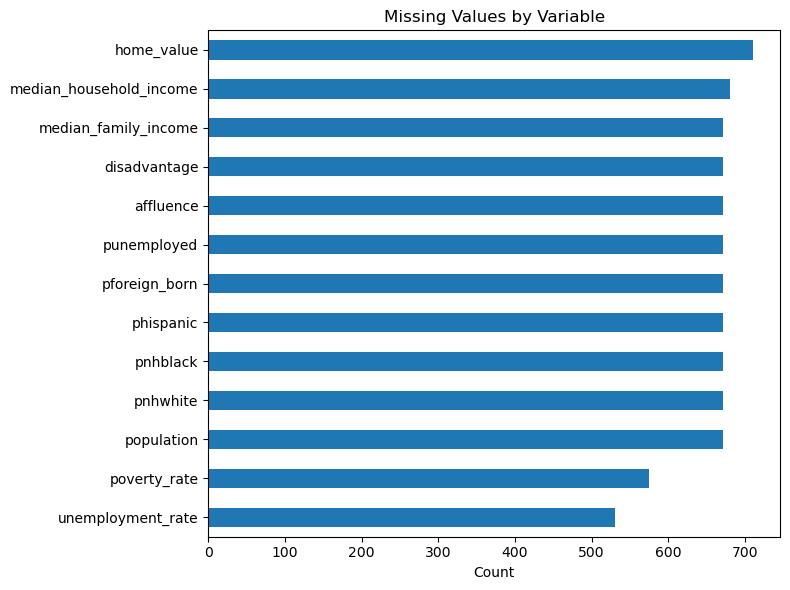

In [6]:
missing[missing > 0].sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Missing Values by Variable")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## 3. Distribution of Key Variables

We examine the distributions of:

- Noise exposure
- Home value
- Median household income
- Poverty rate

These visualizations help identify:

- Skewness
- Outliers
- Data quality issues

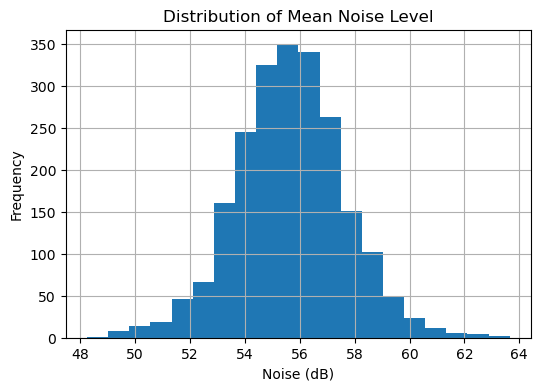

In [7]:
plt.figure(figsize=(6,4))

master["noise_mean_db"].hist(bins=20)

plt.title("Distribution of Mean Noise Level")
plt.xlabel("Noise (dB)")
plt.ylabel("Frequency")

plt.show()

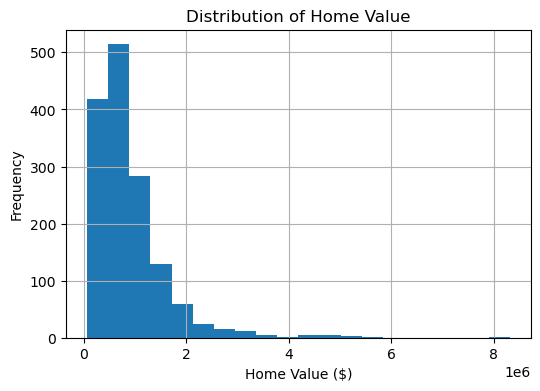

In [8]:
plt.figure(figsize=(6,4))

master["home_value"].dropna().hist(bins=20)

plt.title("Distribution of Home Value")
plt.xlabel("Home Value ($)")
plt.ylabel("Frequency")

plt.show()

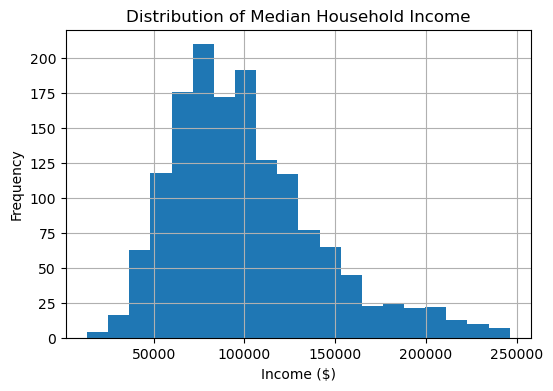

In [9]:
plt.figure(figsize=(6,4))

master["median_household_income"].dropna().hist(bins=20)

plt.title("Distribution of Median Household Income")
plt.xlabel("Income ($)")
plt.ylabel("Frequency")

plt.show()

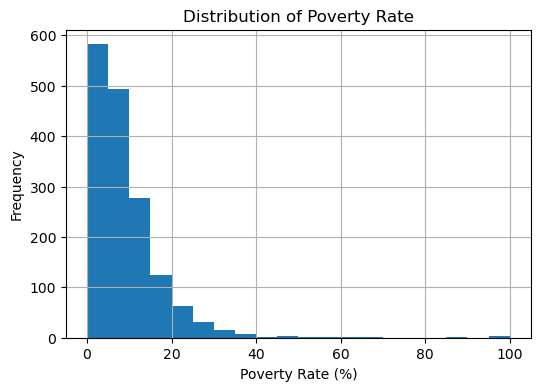

In [10]:
plt.figure(figsize=(6,4))

master["poverty_rate"].dropna().hist(bins=20)

plt.title("Distribution of Poverty Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Frequency")

plt.show()

## 4. Relationships with Noise Exposure

Next, we examine whether transportation noise is associated with:

- Housing value
- Household income
- Poverty rate

Scatterplots provide a first visual assessment of these relationships.

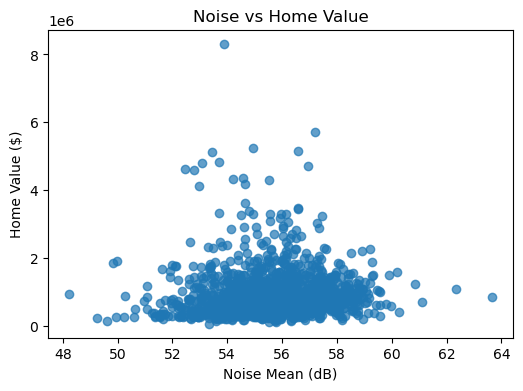

In [11]:
plt.figure(figsize=(6,4))

plt.scatter(
    master["noise_mean_db"],
    master["home_value"],
    alpha=0.7
)

plt.xlabel("Noise Mean (dB)")
plt.ylabel("Home Value ($)")
plt.title("Noise vs Home Value")

plt.show()

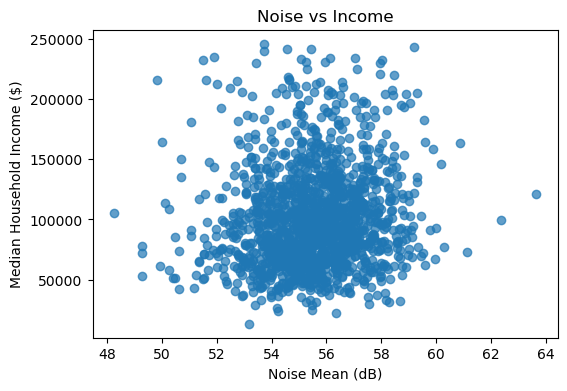

In [12]:
plt.figure(figsize=(6,4))

plt.scatter(
    master["noise_mean_db"],
    master["median_household_income"],
    alpha=0.7
)

plt.xlabel("Noise Mean (dB)")
plt.ylabel("Median Household Income ($)")
plt.title("Noise vs Income")

plt.show()

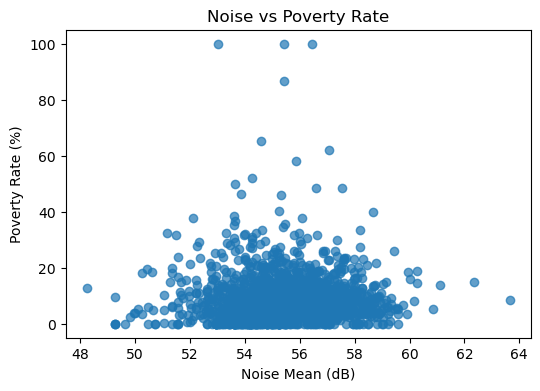

In [13]:
plt.figure(figsize=(6,4))

plt.scatter(
    master["noise_mean_db"],
    master["poverty_rate"],
    alpha=0.7
)

plt.xlabel("Noise Mean (dB)")
plt.ylabel("Poverty Rate (%)")
plt.title("Noise vs Poverty Rate")

plt.show()

## 5. Correlation Analysis

Correlation analysis helps identify linear relationships between variables.

Strong correlations may indicate:

- Important predictors for modeling
- Potential multicollinearity issues

In [14]:
corr = master.corr(numeric_only=True)

corr

,zcta,noise_mean_db,noise_max_db,noise_min_db,median_household_income,unemployment_rate,population,pnhwhite,pnhblack,phispanic,pforeign_born,punemployed,affluence,disadvantage,median_family_income,home_value,poverty_rate
zcta,1.000000,-0.241395,-0.162333,-0.171105,-0.036042,-0.162529,-0.345536,0.381829,-0.230036,-0.310700,-0.398747,-0.041400,-0.060091,-0.053961,0.007943,-0.205752,-0.066483
noise_mean_db,-0.241395,1.000000,0.798816,-0.102970,0.096448,0.141094,0.171073,-0.217200,0.140881,0.084255,0.239047,-0.027014,0.093802,-0.025378,0.053791,0.079660,-0.000354
noise_max_db,-0.162333,0.798816,1.000000,-0.183985,0.069117,0.120530,0.102356,-0.220882,0.087859,0.146934,0.209252,0.008466,0.040223,0.005888,0.040420,0.056433,0.018366
noise_min_db,-0.171105,-0.102970,-0.183985,1.000000,0.044547,0.098714,0.159133,-0.143339,0.106734,0.045363,0.181703,-0.048617,0.058380,-0.015028,0.036989,0.079346,0.005127
median_household_income,-0.036042,0.096448,0.069117,0.044547,1.000000,0.395872,0.080010,0.207639,-0.129464,-0.433865,0.068656,-0.385101,0.831060,-0.737193,0.902068,0.708887,-0.563674
unemployment_rate,-0.162529,0.141094,0.120530,0.098714,0.395872,1.000000,0.349699,-0.227537,0.077856,0.058160,0.355262,-0.372576,0.360769,-0.327098,0.325918,0.254003,-0.187062
population,-0.345536,0.171073,0.102356,0.159133,0.080010,0.349699,1.000000,-0.512372,0.248819,0.323370,0.445236,-0.078992,0.000698,-0.019086,-0.003630,0.037408,0.019567
pnhwhite,0.381829,-0.217200,-0.220882,-0.143339,0.207639,-0.227537,-0.512372,1.000000,-0.389502,-0.790647,-0.752261,-0.119839,0.379058,-0.381893,0.320147,0.153720,-0.372962
pnhblack,-0.230036,0.140881,0.087859,0.106734,-0.129464,0.077856,0.248819,-0.389502,1.000000,0.114695,0.128758,0.067008,-0.106404,0.202715,-0.147861,-0.106555,0.154990
phispanic,-0.310700,0.084255,0.146934,0.045363,-0.433865,0.058160,0.323370,-0.790647,0.114695,1.000000,0.475185,0.202938,-0.635934,0.501587,-0.526600,-0.338420,0.472148


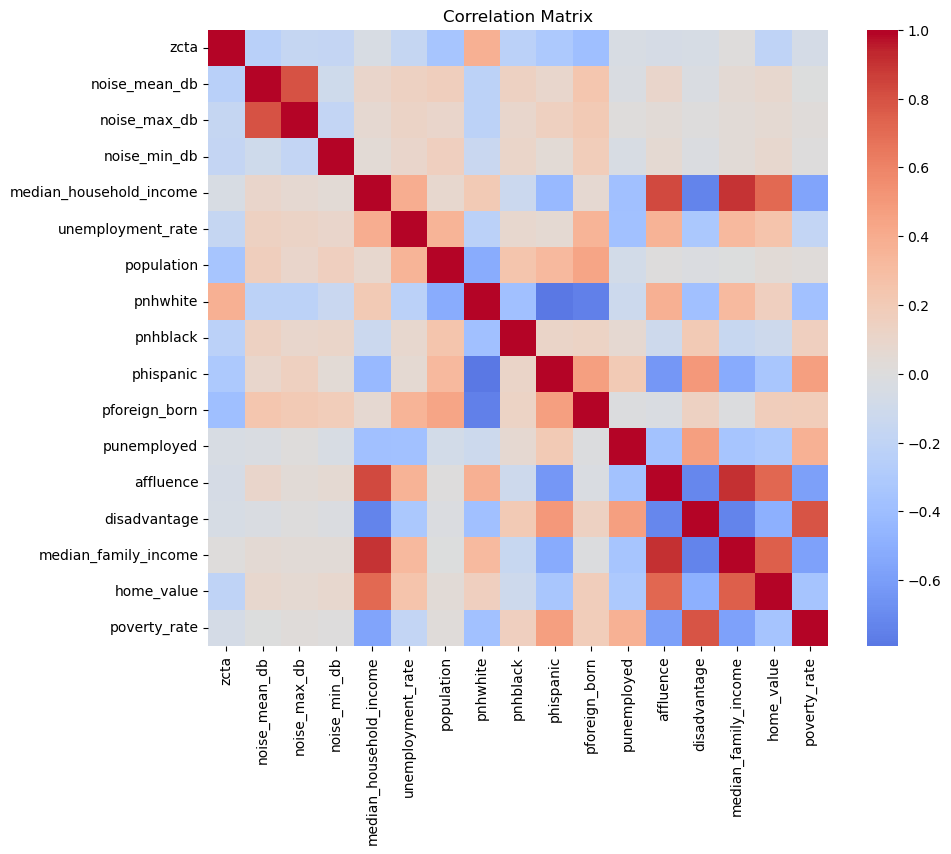

In [15]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Correlations with Transportation Noise

To better understand which variables are associated with transportation noise exposure, we examine the correlations between `noise_mean_db` and all other variables.

Most socioeconomic variables show only weak correlations with transportation noise, suggesting that transportation noise alone may not strongly explain variation in socioeconomic conditions across San Diego County.

In [16]:
corr["noise_mean_db"].sort_values(
    ascending=False
)

noise_mean_db              1.000000
noise_max_db               0.798816
pforeign_born              0.239047
population                 0.171073
unemployment_rate          0.141094
pnhblack                   0.140881
median_household_income    0.096448
affluence                  0.093802
phispanic                  0.084255
home_value                 0.079660
median_family_income       0.053791
poverty_rate              -0.000354
disadvantage              -0.025378
punemployed               -0.027014
noise_min_db              -0.102970
pnhwhite                  -0.217200
zcta                      -0.241395
Name: noise_mean_db, dtype: float64

## Preliminary Findings

Based on the exploratory analysis, several important patterns emerged.

### Transportation Noise Distribution

The distribution of mean transportation noise appears approximately centered around 56 dB, with most ZCTAs falling between 54 and 58 dB. A small number of areas experience substantially higher noise exposure above 60 dB.

### Housing and Socioeconomic Variables

Home values are strongly right-skewed, with a few ZCTAs exhibiting extremely high housing prices. Median household income is more evenly distributed, while poverty rates are concentrated at relatively low levels with several high-poverty outliers.

### Noise and Socioeconomic Conditions

The scatterplots suggest that transportation noise has only weak relationships with home value, income, and poverty rate. No strong linear pattern is immediately visible. This indicates that transportation noise alone may not explain socioeconomic variation across San Diego County.

### Missing Data Issues

Several socioeconomic variables contain substantial missing data. Many ACS-derived variables are missing for approximately 30% of ZCTAs. Appropriate handling of missing observations will be necessary during the modeling stage.

### Variables for Modeling

Potential predictors for future modeling include:

- noise_mean_db
- median_household_income
- poverty_rate
- affluence
- disadvantage
- pforeign_born
- unemployment_rate

The correlation matrix suggests that some socioeconomic variables are highly correlated with one another, which may create multicollinearity issues in regression models. Variable selection techniques may therefore be useful during model development.